# Example set - Builders Temeplate include

In [ ]:
# solve_my_robot_with_param.py
import numpy as np
import matplotlib.pyplot as plt

from admiser import OCPSolver

## No system parameters, pure OCP

Optimization terminated successfully    (Exit mode 0)
            Current function value: 6.18595306575384
            Iterations: 43
            Function evaluations: 46
            Gradient evaluations: 43

=== 报告 ===
theta_opt: None
J*: 6.18595306575384
equality constraint residual (includes ∫L·dt terms):
[-5.44542571e-11  6.10763124e-11 -1.36785657e-15 -7.99951771e-12
  8.76247942e-12 -1.78676518e-16]


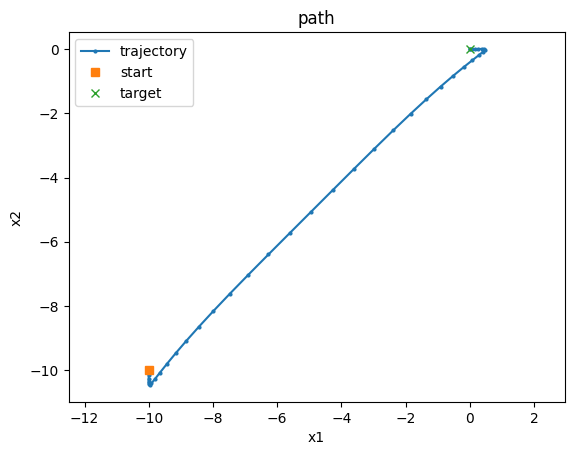

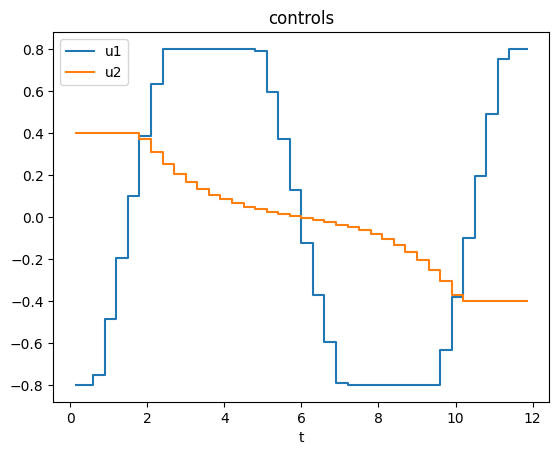

In [ ]:
# solve_my_robot_with_param.py
from admiser.examples.my_robot_problem import problem, N, dt, x0, xT

def main():
    solver = OCPSolver(problem).build()
    result = solver.solve(maxiter=500, ftol=1e-9, disp=True)

    U_opt     = result["U_opt"]
    theta_opt = result["theta_opt"]
    X_opt     = result["X_opt"]
    t_opt     = result["t_opt"]
    J_opt     = result["J_opt"]
    eq_err  = result["eq_resid"]       # 原有等式 + 每条路径不等式积分（应≈0）
    ineq_err= result["ineq_resid"]    # 每条路径不等式最大违反量（应≈0）

    print("\n=== 报告 ===")
    print("theta_opt:", theta_opt)
    print("J*:", J_opt)
    if eq_err is not None:
        print("equality constraint residual (includes ∫L·dt terms):")
        print(eq_err)
    if ineq_err is not None:
        print("inequality constraint residual (includes ∫L·dt terms):")
        print(ineq_err)

    # 轨迹图
    plt.figure()
    plt.plot(X_opt[:,0], X_opt[:,1], '-o', ms=2, label='trajectory')
    plt.plot(x0[0], x0[1], 's', label='start'); plt.plot(xT[0], xT[1], 'x', label='target')
    plt.axis('equal'); plt.legend(); plt.title('path'); plt.xlabel('x1'); plt.ylabel('x2')

    # 控制
    U = U_opt.reshape(N, 2)
    tc = np.linspace(0.0, N*dt, N, endpoint=False) + 0.5*dt
    plt.figure(); plt.step(tc, U[:,0], where='mid', label='u1'); plt.step(tc, U[:,1], where='mid', label='u2')
    plt.legend(); plt.title('controls'); plt.xlabel('t')

    plt.show()

if __name__ == "__main__":
    main()


## Pure OCP - initial guess sensitive

Optimization terminated successfully    (Exit mode 0)
            Current function value: -0.3534320535208112
            Iterations: 248
            Function evaluations: 249
            Gradient evaluations: 248

=== 结果 ===
J* = -0.3534320535208112


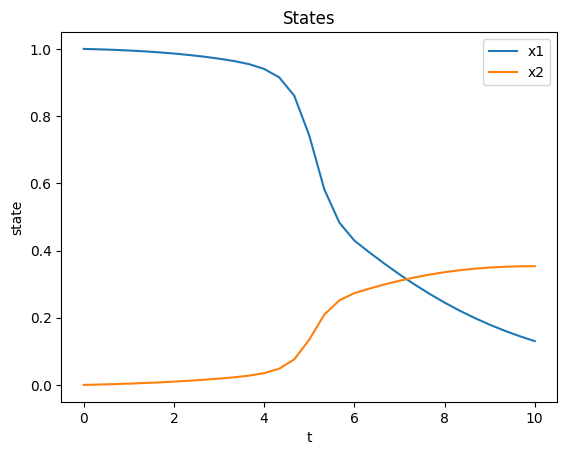

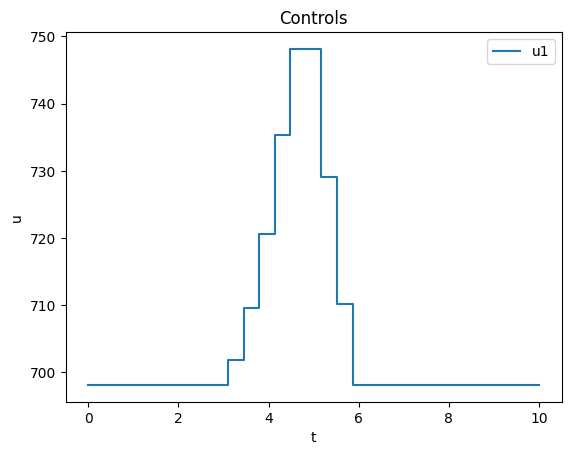

In [ ]:
# solve_my_ocp_problem_tpl.py
from admiser.examples.my_bitumen_pyrolysis import problem, N, dt

def main():
    solver = OCPSolver(problem).build()
    res = solver.solve(maxiter=2000, ftol=1e-9, disp=True)

    U_opt  = res["U_opt"]              # shape = (N*nu,) 或 (N,nu) 由你的实现而定
    theta  = res.get("theta_opt", None)
    J_opt  = res["J_opt"]
    X_opt  = res["X_opt"]              # shape = (N+1, nx)
    t_opt  = res["t_opt"]              # shape = (N+1,)
    eq_res = res.get("eq_res", None)   # 若 OCPSolver 返回了等式残差
    in_res = res.get("ineq_res", None) # 若 OCPSolver 返回了不等式残差

    print("\n=== 结果 ===")
    print("J* =", J_opt)
    if theta is not None:
        print("theta* =", theta)
    if eq_res is not None:
        print("eq residual:", eq_res)
    if in_res is not None:
        print("ineq residual:", in_res)

    # 状态
    plt.figure()
    for i in range(X_opt.shape[1]):
        plt.plot(t_opt, X_opt[:, i], label=f"x{i+1}")
    plt.xlabel("t"); plt.ylabel("state"); plt.title("States"); plt.legend()

    # 控制（分段常值 → N 段；若 U_opt 是扁平向量，reshape 一下）
    nu = problem.nu
    U_mat = U_opt.reshape(N, nu) if U_opt.ndim == 1 else U_opt
    tc = np.linspace(0.0, np.sum(np.diff(t_opt)), N)  # 固定dt时等于 np.linspace(0,T,N)
    plt.figure()
    for j in range(nu):
        plt.step(tc, U_mat[:, j], where='pre', label=f"u{j+1}")
    plt.xlabel("t"); plt.ylabel("u"); plt.title("Controls"); plt.legend()

    plt.show()

if __name__ == "__main__":
    main()


# System parameters are included

## Feedback control

Optimization terminated successfully    (Exit mode 0)
            Current function value: 23.494589135579474
            Iterations: 17
            Function evaluations: 17
            Gradient evaluations: 17

=== 报告 ===
theta_opt [z1,z2,z3,z4] = [-10.         -10.          -2.50109108   2.18111977]
J* = 23.494589135579474


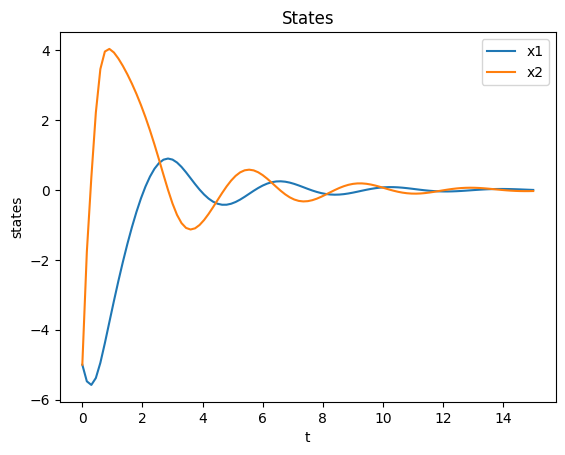

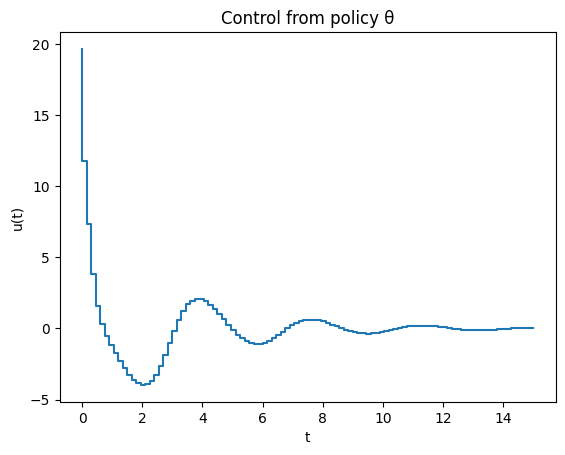

In [ ]:
from admiser.examples.my_policy_param_problem import problem, N, dt, policy_u

def main():
    solver = OCPSolver(problem).build()
    result = solver.solve(maxiter=600, ftol=1e-9, disp=True)

    U_opt     = result["U_opt"]        # 这里长度=0（nu=0）
    theta_opt = result["theta_opt"]    # 最优 [ζ1..ζ4]
    X_opt     = result["X_opt"]
    t_opt     = result["t_opt"]
    J_opt     = result["J_opt"]

    print("\n=== 报告 ===")
    print("theta_opt [z1,z2,z3,z4] =", theta_opt)
    print("J* =", J_opt)

    # 由最优 theta 计算 u(t) 轨迹（用于可视化）
    U_series = np.array([ float(policy_u(x, theta_opt)) for x in X_opt ])

    # 画状态
    plt.figure()
    plt.plot(t_opt, X_opt[:,0], label='x1')
    plt.plot(t_opt, X_opt[:,1], label='x2')
    plt.xlabel('t'); plt.ylabel('states'); plt.title('States'); plt.legend()

    # 画控制（用区间左端值）
    tc = np.linspace(0.0, N*dt, N+1)
    plt.figure()
    plt.step(tc, U_series, where='pre')
    plt.xlabel('t'); plt.ylabel('u(t)'); plt.title('Control from policy θ')

    plt.show()

if __name__ == "__main__":
    main()

## Recursive control

Optimization terminated successfully    (Exit mode 0)
            Current function value: -0.5759369967459305
            Iterations: 184
            Function evaluations: 185
            Gradient evaluations: 184

=== 最优解（关键量） ===
ζ1 = 0.030520,  ζ2 = 0.575937   (目标为 -ζ2 = -0.575936997)
J* = -0.575936997
u_max = 6.0


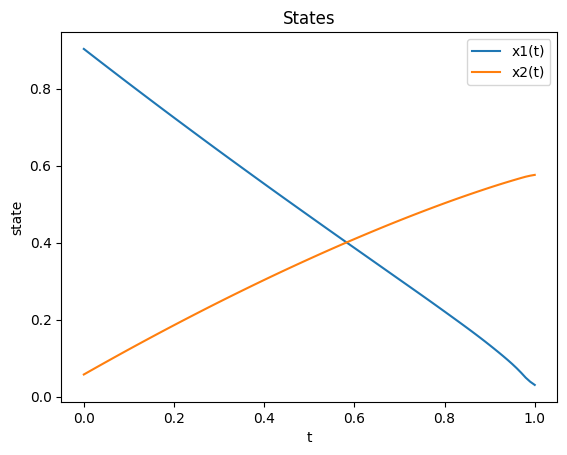

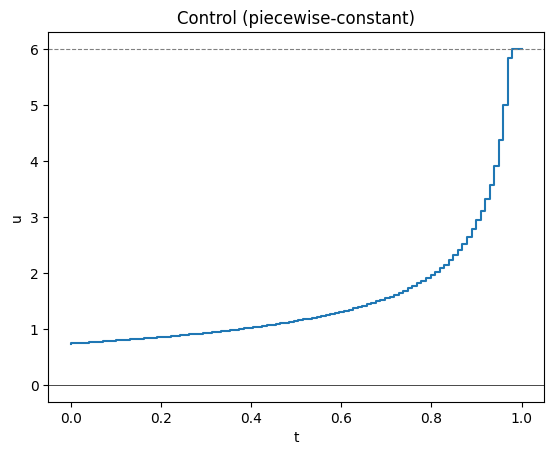

In [ ]:
# solve_ex_882_theta_zeta.py
from admiser.examples.my_ex_882_zeta_param import problem, N, dt, u_max

def main():
    solver = OCPSolver(problem).build()
    # 有2条等式约束 → 一般走 SLSQP；你的 OCPSolver 若有“自动选法”会自动选
    res = solver.solve(maxiter=800, ftol=1e-9, disp=True)

    U_opt     = res["U_opt"]        # shape=(N,)
    theta_opt = res["theta_opt"]    # [ζ1, ζ2]
    J_opt     = res["J_opt"]
    X_opt     = res["X_opt"]
    t_opt     = res["t_opt"]

    z1, z2 = theta_opt
    print("\n=== 最优解（关键量） ===")
    print(f"ζ1 = {z1:.6f},  ζ2 = {z2:.6f}   (目标为 -ζ2 = {-z2:.9f})")
    print(f"J* = {J_opt:.9f}")
    print(f"u_max = {u_max}")

    plt.figure()
    plt.plot(t_opt, X_opt[:,0], label='x1(t)')
    plt.plot(t_opt, X_opt[:,1], label='x2(t)')
    plt.xlabel('t'); plt.ylabel('state'); plt.title('States'); plt.legend()

    tc = np.linspace(0.0, N*dt, N)
    plt.figure()
    plt.step(tc, U_opt, where='pre')
    plt.axhline(0.0, color='k', lw=0.5)
    plt.axhline(u_max, color='gray', ls='--', lw=0.8)
    plt.xlabel('t'); plt.ylabel('u'); plt.title('Control (piecewise-constant)')

    plt.show()

if __name__ == "__main__":
    main()


# Continuous state and control inequality constraints

## Simple example - continuous state inequality

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.1705160387400097
            Iterations: 269
            Function evaluations: 311
            Gradient evaluations: 269

=== 结果 ===
J* = 0.1705160387400097
inequality constraint residual (includes ∫L·dt terms):
[-1.1170039e-14]


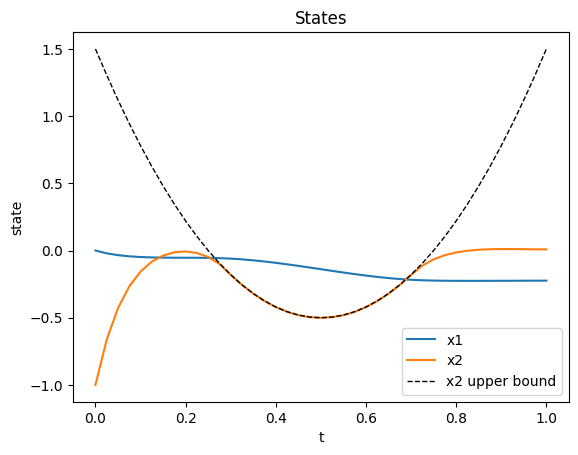

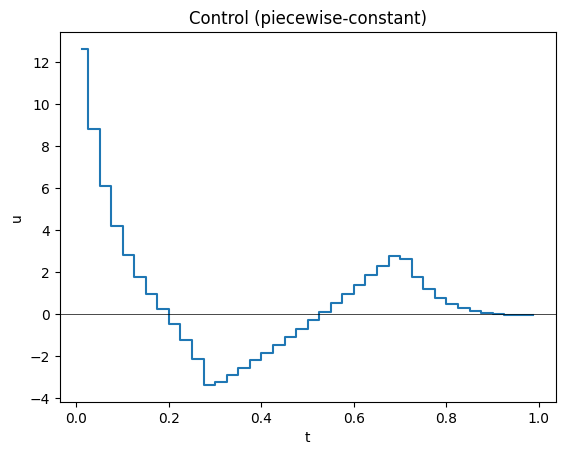

In [ ]:
# solve_state_constrained.py
from admiser.examples.my_state_constrained_problem import problem, N, dt

def main():
    solver = OCPSolver(problem).build()
    res = solver.solve(maxiter=1000, ftol=1e-12, disp=True)
    # 如你已实现外层 homotopy，可改：solve(..., homotopy=True, outer_iters=5, shrink=0.5)

    U_opt     = res["U_opt"]          # shape=(N,)
    J_opt     = res["J_opt"]
    X_opt     = res["X_opt"]          # shape=(N+1, 2)
    t_opt     = res["t_opt"]          # shape=(N+1,)
    eq_err  = res["eq_resid"]       # 原有等式 + 每条路径不等式积分（应≈0）
    ineq_err= res["ineq_resid"]    # 每条路径不等式最大违反量（应≈0）

    print("\n=== 结果 ===")
    print("J* =", J_opt)
    if eq_err is not None:
        print("equality constraint residual (includes ∫L·dt terms):")
        print(eq_err)
    if ineq_err is not None:
        print("inequality constraint residual (includes ∫L·dt terms):")
        print(ineq_err)

    # ---- 画状态轨迹 ----
    plt.figure()
    plt.plot(t_opt, X_opt[:,0], label='x1')
    plt.plot(t_opt, X_opt[:,1], label='x2')
    plt.xlabel('t'); plt.ylabel('state'); plt.title('States'); plt.legend()

    # 画约束上界曲线：x2 ≤ 8*(t-0.5)^2 - 0.5
    x2_cap = 8.0 * (t_opt - 0.5)**2 - 0.5
    plt.plot(t_opt, x2_cap, 'k--', lw=1.0, label='x2 upper bound')
    plt.legend()

    # ---- 画控制（阶梯）----
    tc = np.linspace(0.0, N*dt, N, endpoint=False) + 0.5*dt
    plt.figure()
    plt.step(tc, U_opt, where='mid')
    plt.axhline(0.0, color='k', lw=0.5)
    plt.xlabel('t'); plt.ylabel('u'); plt.title('Control (piecewise-constant)')

    plt.show()

if __name__ == "__main__":
    main()


## Continuous state and control constraint

Optimization terminated successfully    (Exit mode 0)
            Current function value: 45.32926253576728
            Iterations: 106
            Function evaluations: 197
            Gradient evaluations: 106

=== 结果 ===
J* = 45.32926253576728


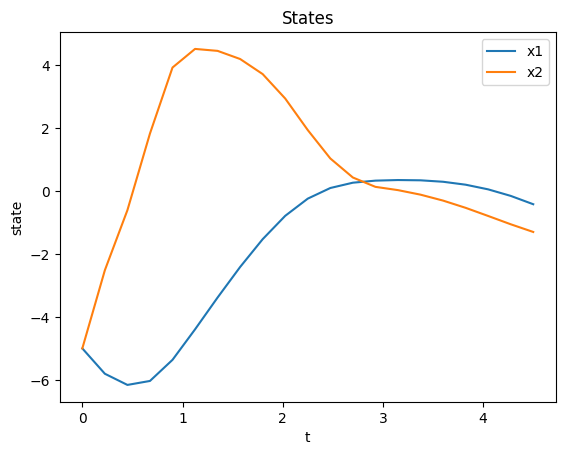

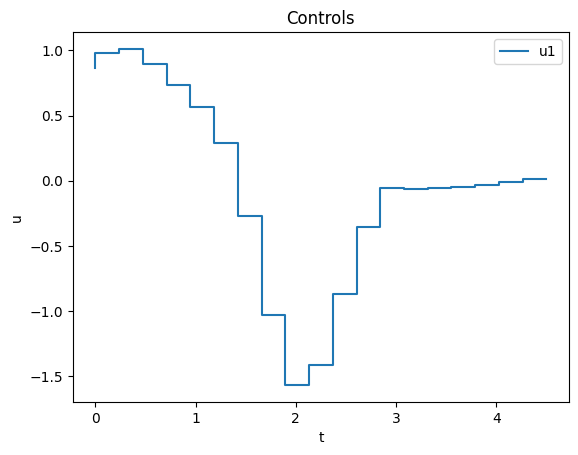

In [ ]:
# solve_my_ocp_problem_tpl.py
from admiser.examples.my_state_control_constraint import problem, N, dt

def main():
    solver = OCPSolver(problem).build()
    res = solver.solve(maxiter=2000, ftol=1e-9, disp=True)

    U_opt  = res["U_opt"]              # shape = (N*nu,) 或 (N,nu) 由你的实现而定
    theta  = res.get("theta_opt", None)
    J_opt  = res["J_opt"]
    X_opt  = res["X_opt"]              # shape = (N+1, nx)
    t_opt  = res["t_opt"]              # shape = (N+1,)
    eq_res = res.get("eq_res", None)   # 若 OCPSolver 返回了等式残差
    in_res = res.get("ineq_res", None) # 若 OCPSolver 返回了不等式残差

    print("\n=== 结果 ===")
    print("J* =", J_opt)
    if theta is not None:
        print("theta* =", theta)
    if eq_res is not None:
        print("eq residual:", eq_res)
    if in_res is not None:
        print("ineq residual:", in_res)

    # 状态
    plt.figure()
    for i in range(X_opt.shape[1]):
        plt.plot(t_opt, X_opt[:, i], label=f"x{i+1}")
    plt.xlabel("t"); plt.ylabel("state"); plt.title("States"); plt.legend()

    # 控制（分段常值 → N 段；若 U_opt 是扁平向量，reshape 一下）
    nu = problem.nu
    U_mat = U_opt.reshape(N, nu) if U_opt.ndim == 1 else U_opt
    tc = np.linspace(0.0, np.sum(np.diff(t_opt)), N)  # 固定dt时等于 np.linspace(0,T,N)
    plt.figure()
    for j in range(nu):
        plt.step(tc, U_mat[:, j], where='pre', label=f"u{j+1}")
    plt.xlabel("t"); plt.ylabel("u"); plt.title("Controls"); plt.legend()

    plt.show()

if __name__ == "__main__":
    main()


## More commplicate problem - kobe port

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.005256916302456451
            Iterations: 148
            Function evaluations: 154
            Gradient evaluations: 148

=== 结果 ===
J* = 0.005256916302456451
terminal equality residual (x(T)-xT): [ 5.52837776e-10 -1.24344979e-14 -5.15194869e-12  1.04062092e-10
  1.66533454e-16 -4.10706538e-12]
ineq residuals (gamma - g_eps) >= 0: [ 1.00000000e-03  1.00000000e-03  1.00000000e-03 -9.08973937e-10]


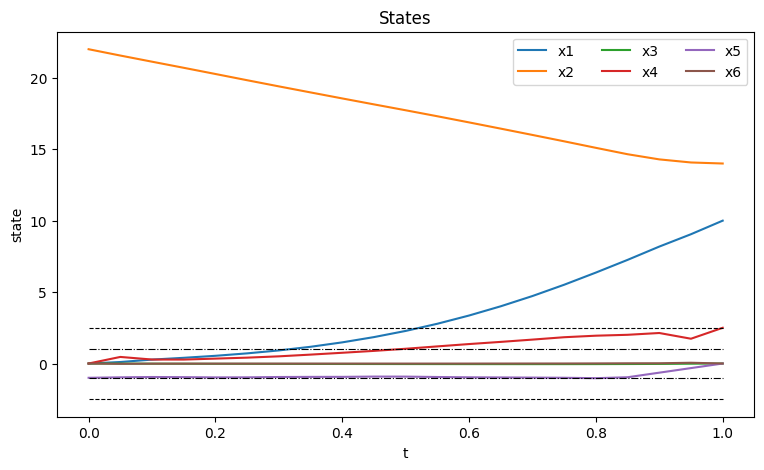

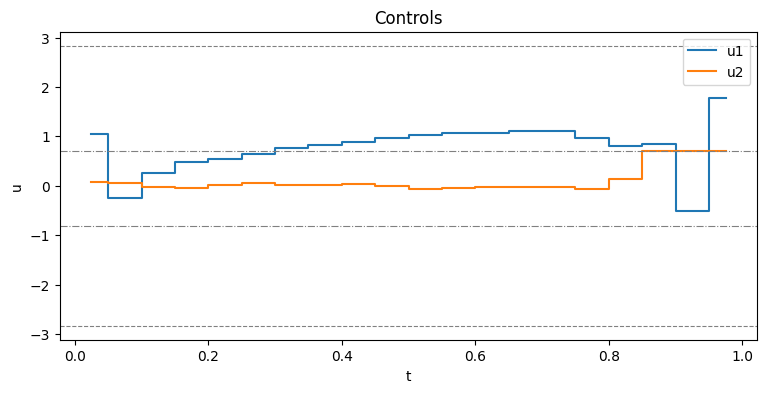

In [ ]:
# solve_six_state.py
from admiser.examples.my_port_kobe import problem, T, N, dt

def main():
    solver = OCPSolver(problem).build()
    res = solver.solve(maxiter=2000, ftol=1e-8, disp=True)

    U_opt    = res["U_opt"]          # shape = (2N,)
    X_opt    = res["X_opt"]          # shape = (N+1, 6)
    t_opt    = res["t_opt"]          # shape = (N+1,)
    eq_resid = res["eq_resid"]
    inq_res  = res["ineq_resid"]

    print("\n=== 结果 ===")
    print("J* =", res["J_opt"])
    if eq_resid is not None:
        print("terminal equality residual (x(T)-xT):", eq_resid)
    if inq_res is not None:
        print("ineq residuals (gamma - g_eps) >= 0:", inq_res)

    # 状态图
    plt.figure(figsize=(9,5))
    labels = ['x1','x2','x3','x4','x5','x6']
    for i in range(6):
        plt.plot(t_opt, X_opt[:, i], label=labels[i])
    # 约束上下界线
    plt.plot(t_opt,  2.5*np.ones_like(t_opt), 'k--', lw=0.8)   # x4<=2.5
    plt.plot(t_opt, -2.5*np.ones_like(t_opt), 'k--', lw=0.8)   # x4>=-2.5
    plt.plot(t_opt,  1.0*np.ones_like(t_opt), 'k-.', lw=0.8)   # x5<=1.0
    plt.plot(t_opt, -1.0*np.ones_like(t_opt), 'k-.', lw=0.8)   # x5>=-1.0
    plt.xlabel('t'); plt.ylabel('state'); plt.title('States'); plt.legend(ncol=3)

    # 控制图（阶梯）
    U = U_opt.reshape(N, 2)
    tc = np.linspace(0.0, T, N, endpoint=False) + 0.5*dt
    plt.figure(figsize=(9,4))
    plt.step(tc, U[:,0], where='mid', label='u1')
    plt.step(tc, U[:,1], where='mid', label='u2')
    plt.axhline( 2.83374, color='gray', ls='--', lw=0.8)
    plt.axhline(-2.83374, color='gray', ls='--', lw=0.8)
    plt.axhline( 0.71265, color='gray', ls='-.',  lw=0.8)
    plt.axhline(-0.80865, color='gray', ls='-.',  lw=0.8)
    plt.xlabel('t'); plt.ylabel('u'); plt.title('Controls'); plt.legend()

    plt.show()

if __name__ == "__main__":
    main()


## Optimal Euler buckling beam - continuous inequality and system parameters

Optimization terminated successfully    (Exit mode 0)
            Current function value: -12.7656227163776
            Iterations: 121
            Function evaluations: 162
            Gradient evaluations: 121

=== 结果 ===
J*     = -12.7656227163776
eq residual (x1(T), ∫x3-1): [-4.92388335e-12 -1.22124533e-15]
ineq residuals (gamma - g_eps) >= 0: [-7.31790253e-15]
z1* = 12.765623,  z2* = 0.500000


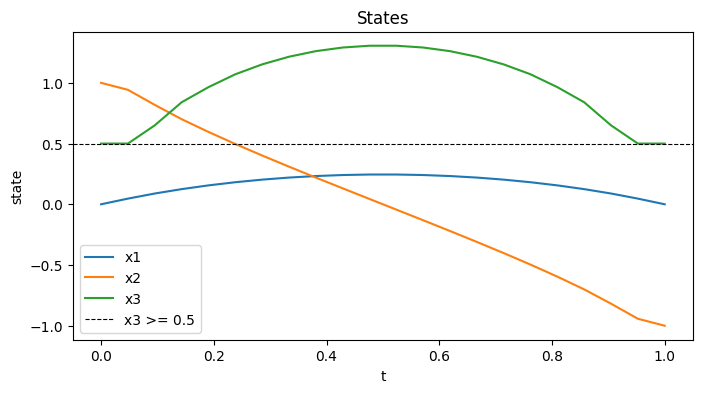

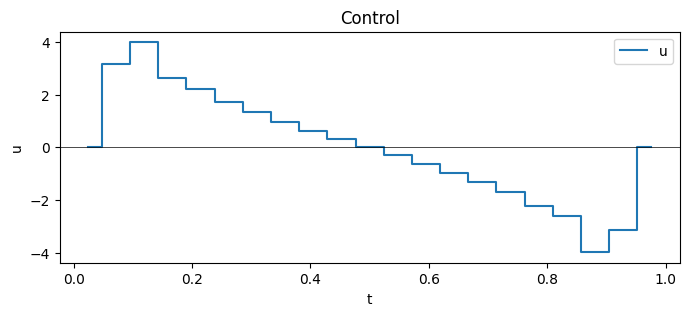

In [ ]:
# solve_z1z2_problem.py
from admiser.examples.my_euler_buckling_beam import problem, T, N, dt

def main():
    solver = OCPSolver(problem).build()
    res = solver.solve(maxiter=2000, ftol=1e-9, disp=True)

    U_opt    = res["U_opt"]          # shape=(N,)
    X_opt    = res["X_opt"]          # shape=(N+1, 3)
    t_opt    = res["t_opt"]
    eq_resid = res["eq_resid"]       # [ x1(T)-0 , ∫x3-1 ]
    inq_res  = res["ineq_resid"]     # [ gamma - g_eps ]  (>=0)

    print("\n=== 结果 ===")
    print("J*     =", res["J_opt"])
    if eq_resid is not None:
        print("eq residual (x1(T), ∫x3-1):", eq_resid)
    if inq_res is not None:
        print("ineq residuals (gamma - g_eps) >= 0:", inq_res)

    # 打印参数
    theta_opt = res["theta_opt"]     # [z1, z2]
    z1, z2 = theta_opt
    print(f"z1* = {z1:.6f},  z2* = {z2:.6f}")

    # 画状态
    plt.figure(figsize=(8,4))
    plt.plot(t_opt, X_opt[:,0], label='x1')
    plt.plot(t_opt, X_opt[:,1], label='x2')
    plt.plot(t_opt, X_opt[:,2], label='x3')
    plt.axhline(0.5, color='k', ls='--', lw=0.8, label='x3 >= 0.5')
    plt.xlabel('t'); plt.ylabel('state'); plt.title('States'); plt.legend()

    # 画控制（阶梯）
    tc = np.linspace(0.0, T, N, endpoint=False) + 0.5*dt
    plt.figure(figsize=(8,3))
    plt.step(tc, U_opt, where='mid', label='u')
    plt.axhline(0.0, color='k', lw=0.5)
    plt.xlabel('t'); plt.ylabel('u'); plt.title('Control'); plt.legend()

    plt.show()

if __name__ == "__main__":
    main()


# Bang-bang control

Optimization terminated successfully    (Exit mode 0)
            Current function value: -41.30126336248545
            Iterations: 65
            Function evaluations: 65
            Gradient evaluations: 65

=== 结果 ===
J* = -41.30126336248545


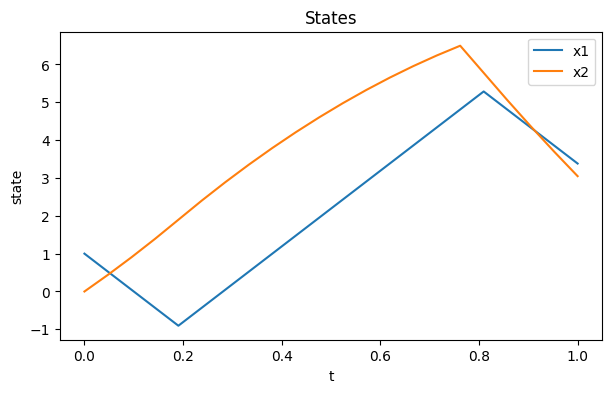

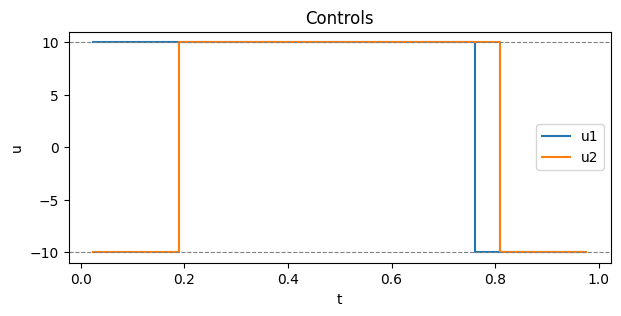

In [ ]:
# solve_lin2x2.py
from admiser.examples.my_bang_bang import problem, T, N, dt

def main():
    solver = OCPSolver(problem).build()
    res = solver.solve(maxiter=2000, ftol=1e-8, disp=True)

    U_opt    = res["U_opt"]         # shape = (2N,)
    X_opt    = res["X_opt"]         # shape = (N+1, 2)
    t_opt    = res["t_opt"]

    print("\n=== 结果 ===")
    print("J* =", res["J_opt"])
    if res["eq_resid"]   is not None: print("eq residual:",   res["eq_resid"])
    if res["ineq_resid"] is not None: print("ineq residual:", res["ineq_resid"])

    # 状态轨迹
    plt.figure(figsize=(7,4))
    plt.plot(t_opt, X_opt[:,0], label='x1')
    plt.plot(t_opt, X_opt[:,1], label='x2')
    plt.xlabel('t'); plt.ylabel('state'); plt.title('States'); plt.legend()

    # 控制（阶梯）
    tc = np.linspace(0.0, T, N, endpoint=False) + 0.5*dt
    U = U_opt.reshape(N, problem.nu)
    plt.figure(figsize=(7,3))
    plt.step(tc, U[:,0], where='mid', label='u1')
    plt.step(tc, U[:,1], where='mid', label='u2')
    plt.axhline( 10.0, color='gray', ls='--', lw=0.8)
    plt.axhline(-10.0, color='gray', ls='--', lw=0.8)
    plt.xlabel('t'); plt.ylabel('u'); plt.title('Controls'); plt.legend()

    plt.show()

if __name__ == "__main__":
    main()


# Free Terminal Time

## From Visual MISER

Optimization terminated successfully    (Exit mode 0)
            Current function value: 4.321173554188036
            Iterations: 145
            Function evaluations: 242
            Gradient evaluations: 145

=== 结果 ===
J* = 4.321173554188036


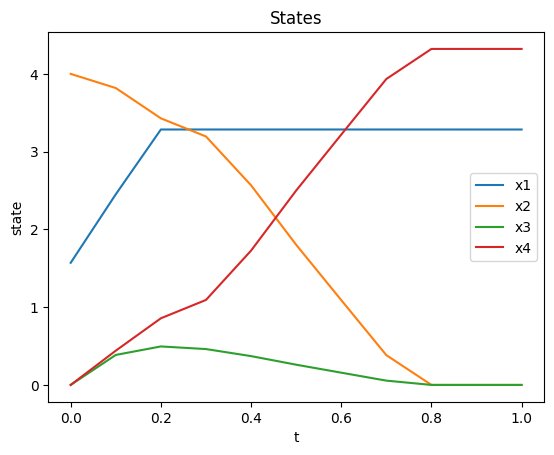

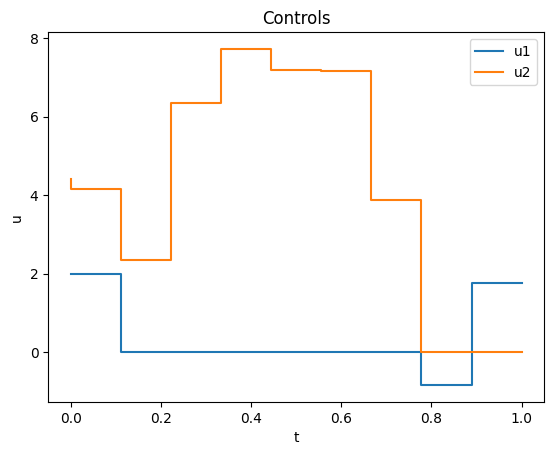

In [ ]:
# solve_my_ocp_problem_tpl.py
from admiser.examples.my_free_terminal_time import problem, N, dt

def main():
    solver = OCPSolver(problem).build()
    res = solver.solve(maxiter=2000, ftol=1e-9, disp=True)

    U_opt  = res["U_opt"]              # shape = (N*nu,) 或 (N,nu) 由你的实现而定
    theta  = res.get("theta_opt", None)
    J_opt  = res["J_opt"]
    X_opt  = res["X_opt"]              # shape = (N+1, nx)
    t_opt  = res["t_opt"]              # shape = (N+1,)
    eq_res = res.get("eq_res", None)   # 若 OCPSolver 返回了等式残差
    in_res = res.get("ineq_res", None) # 若 OCPSolver 返回了不等式残差

    print("\n=== 结果 ===")
    print("J* =", J_opt)
    if theta is not None:
        print("theta* =", theta)
    if eq_res is not None:
        print("eq residual:", eq_res)
    if in_res is not None:
        print("ineq residual:", in_res)

    # 状态
    plt.figure()
    for i in range(X_opt.shape[1]):
        plt.plot(t_opt, X_opt[:, i], label=f"x{i+1}")
    plt.xlabel("t"); plt.ylabel("state"); plt.title("States"); plt.legend()

    # 控制（分段常值 → N 段；若 U_opt 是扁平向量，reshape 一下）
    nu = problem.nu
    U_mat = U_opt.reshape(N, nu) if U_opt.ndim == 1 else U_opt
    tc = np.linspace(0.0, np.sum(np.diff(t_opt)), N)  # 固定dt时等于 np.linspace(0,T,N)
    plt.figure()
    for j in range(nu):
        plt.step(tc, U_mat[:, j], where='pre', label=f"u{j+1}")
    plt.xlabel("t"); plt.ylabel("u"); plt.title("Controls"); plt.legend()

    plt.show()

if __name__ == "__main__":
    main()


## From Teo CPET

Optimization terminated successfully    (Exit mode 0)
            Current function value: 46.17131126128508
            Iterations: 117
            Function evaluations: 299
            Gradient evaluations: 116

=== 结果 ===
J* = 46.17131126128508


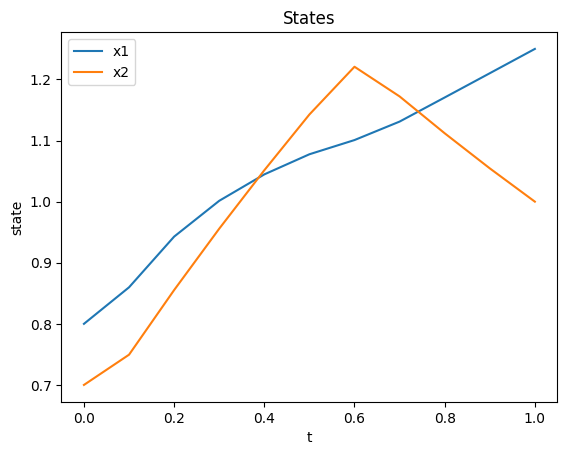

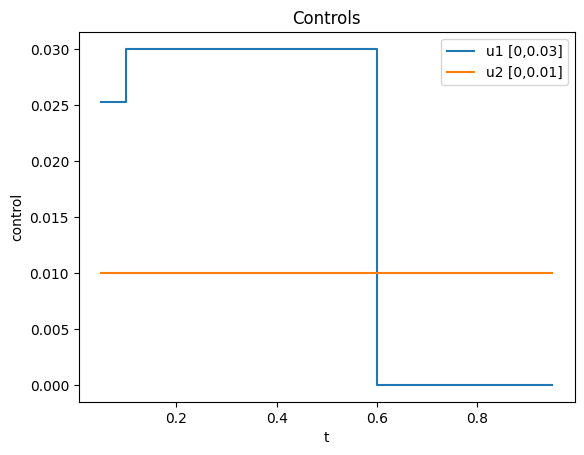

In [ ]:
# solve_ratio_control.py
from admiser.examples.my_free_terminal_time2 import problem, N, dt, T

def main():
    solver = OCPSolver(problem).build()
    res = solver.solve(maxiter=3000, ftol=1e-6, disp=True)

    U_opt = res["U_opt"]          # (N*nu,)
    X_opt = res["X_opt"]          # (N+1, nx)
    t_opt = res["t_opt"]          # (N+1,)
    J_opt = res["J_opt"]
    term  = res.get("term_err", None)

    print("\n=== 结果 ===")
    print(f"J* = {J_opt}")
    if term is not None:
        print("terminal eq residuals:", term)

    # 状态轨迹
    plt.figure()
    plt.plot(t_opt, X_opt[:,0], label="x1")
    plt.plot(t_opt, X_opt[:,1], label="x2")
    # plt.plot(t_opt, X_opt[:,2], label="x3")
    plt.xlabel("t"); plt.ylabel("state"); plt.title("States"); plt.legend()

    # 控制（阶梯图）
    U_mat = U_opt.reshape(N, 3)
    u1 = U_mat[:,0]; u2 = U_mat[:,1]; u3 = U_mat[:,2]
    tc = np.linspace(0.0, T, N, endpoint=False) + 0.5*dt

    plt.figure()
    plt.step(tc, u1, where="mid", label="u1 [0,0.03]")
    plt.step(tc, u2, where="mid", label="u2 [0,0.01]")
    # plt.step(tc, u3, where="mid", label="u3 ≥ 0")
    plt.xlabel("t"); plt.ylabel("control"); plt.title("Controls"); plt.legend()

    plt.show()

if __name__ == "__main__":
    main()


# complicate problem

## Two drugs cancer

Optimization terminated successfully    (Exit mode 0)
            Current function value: 2372828.6148532205
            Iterations: 10
            Function evaluations: 6
            Gradient evaluations: 6

=== 结果 ===
J* = 2372828.6148532205


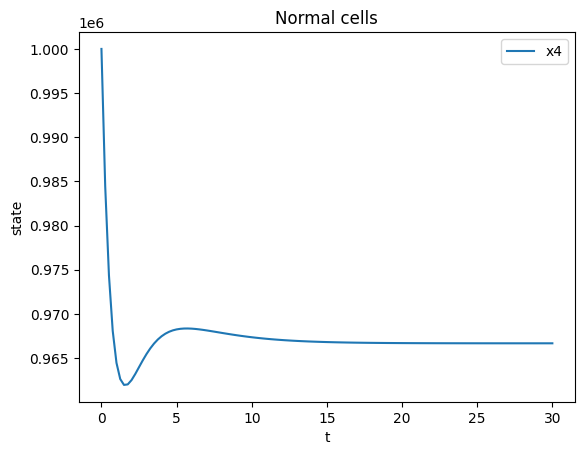

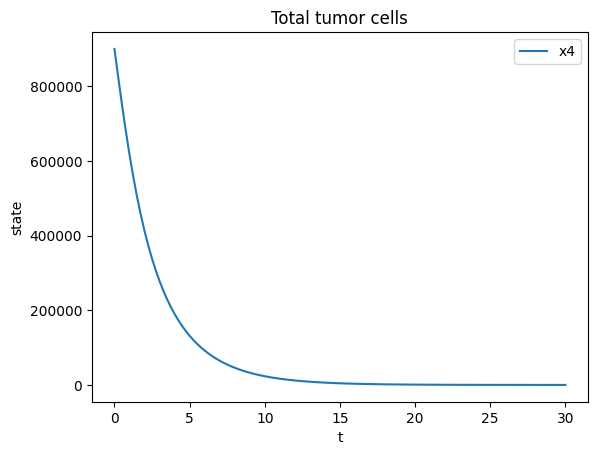

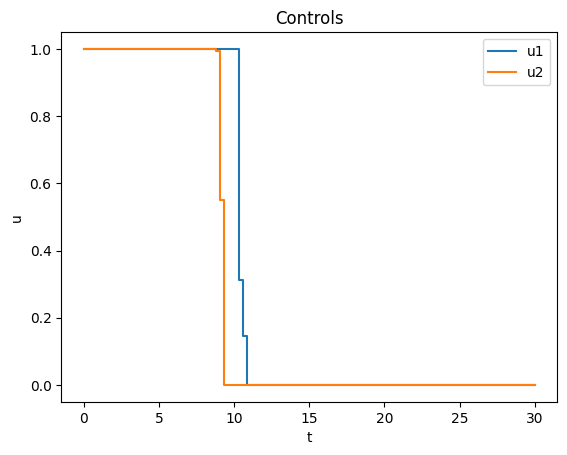

In [ ]:
# solve_my_ocp_problem_tpl.py
from admiser.examples.my_medical1 import problem, N, dt

def main():
    solver = OCPSolver(problem).build()
    res = solver.solve(maxiter=2000, ftol=1e-9, disp=True)

    U_opt  = res["U_opt"]              # shape = (N*nu,) 或 (N,nu) 由你的实现而定
    theta  = res.get("theta_opt", None)
    J_opt  = res["J_opt"]
    X_opt  = res["X_opt"]              # shape = (N+1, nx)
    t_opt  = res["t_opt"]              # shape = (N+1,)
    eq_res = res.get("eq_res", None)   # 若 OCPSolver 返回了等式残差
    in_res = res.get("ineq_res", None) # 若 OCPSolver 返回了不等式残差

    print("\n=== 结果 ===")
    print("J* =", J_opt)
    if theta is not None:
        print("theta* =", theta)
    if eq_res is not None:
        print("eq residual:", eq_res)
    if in_res is not None:
        print("ineq residual:", in_res)

    # 状态
    plt.figure()
    plt.plot(t_opt, X_opt[:, 3], label=f"x{3+1}")
    plt.xlabel("t"); plt.ylabel("state"); plt.title("Normal cells"); plt.legend()

    plt.figure()
    plt.plot(t_opt, X_opt[:, 0] + X_opt[:, 1] + X_opt[:, 2], label=f"x{3+1}")
    plt.xlabel("t"); plt.ylabel("state"); plt.title("Total tumor cells"); plt.legend()

    # 控制（分段常值 → N 段；若 U_opt 是扁平向量，reshape 一下）
    nu = problem.nu
    U_mat = U_opt.reshape(N, nu) if U_opt.ndim == 1 else U_opt
    tc = np.linspace(0.0, np.sum(np.diff(t_opt)), N)  # 固定dt时等于 np.linspace(0,T,N)
    plt.figure()
    for j in range(nu):
        plt.step(tc, U_mat[:, j], where='pre', label=f"u{j+1}")
    plt.xlabel("t"); plt.ylabel("u"); plt.title("Controls"); plt.legend()

    plt.show()

if __name__ == "__main__":
    main()


## SRI

Optimization terminated successfully    (Exit mode 0)
            Current function value: 309.8507113972375
            Iterations: 85
            Function evaluations: 203
            Gradient evaluations: 81

=== 结果 ===
J* = 309.8507113972375
ineq residual(s): [-3.35405253e-07 -2.11740715e-06]

Estimated ∫ u1*S dt = 0.3867 (budget ≤ 0.6)


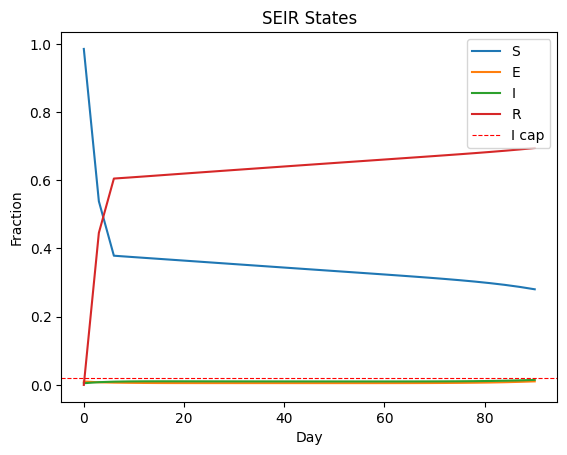

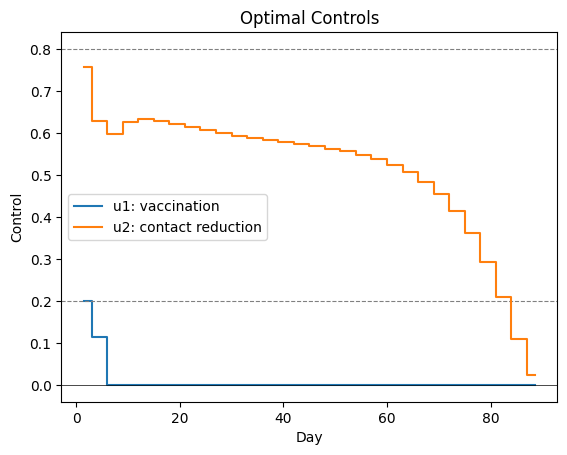

In [ ]:
# solve_covid_seir_ocp.py
from admiser.examples.my_medical2 import problem, N, dt, T, u1_max, u2_max, I_cap, V_budget

def main():
    solver = OCPSolver(problem).build()
    res = solver.solve(maxiter=3000, ftol=1e-6, disp=True)

    print("\n=== 结果 ===")
    print("J* =", res["J_opt"])
    if "term_err" in res and res["term_err"] is not None:
        print("eq residual:", res["term_err"])
    if "ineq_resid" in res and res["ineq_resid"] is not None:
        print("ineq residual(s):", res["ineq_resid"])

    U  = res["U_opt"].reshape(N, -1)   # (N,2)
    t  = res["t_opt"]
    X  = res["X_opt"]                  # (N+1,4): [S,E,I,R]
    S,E,I,R = X[:,0], X[:,1], X[:,2], X[:,3]

    # --- 状态 ---
    plt.figure()
    plt.plot(t, S, label="S")
    plt.plot(t, E, label="E")
    plt.plot(t, I, label="I")
    plt.plot(t, R, label="R")
    plt.axhline(I_cap, color='r', ls='--', lw=0.8, label="I cap")
    plt.xlabel("Day"); plt.ylabel("Fraction")
    plt.title("SEIR States")
    plt.legend()

    # --- 控制 ---
    tc = np.linspace(0.0, T, N, endpoint=False) + 0.5*dt
    plt.figure()
    plt.step(tc, U[:,0], where='mid', label="u1: vaccination")
    plt.axhline(0.0, color='k', lw=0.5)
    plt.axhline(u1_max, color='gray', ls='--', lw=0.8)
    plt.step(tc, U[:,1], where='mid', label="u2: contact reduction")
    plt.axhline(u2_max, color='gray', ls='--', lw=0.8)
    plt.xlabel("Day"); plt.ylabel("Control")
    plt.title("Optimal Controls")
    plt.legend()

    # --- 累计接种用量（∫ u1*S dt）估算 ---
    v_consumed = np.trapezoid(U[:,0] * 0.5*(S[:-1] + S[1:]), dx=dt)
    print(f"\nEstimated ∫ u1*S dt = {v_consumed:.4f} (budget ≤ {V_budget})")

    plt.show()

if __name__ == "__main__":
    main()


### TODO - Problem Scale, Time Scaling
- 线性增长条件，LiP 条件，解存在唯一性